## TASK 4 - Face Mask Detection using Convolutional Neural Networks

Group Number: 14


In [1]:
%load_ext autoreload
%autoreload 1
%aimport my_model, utils, my_datamodule, my_model, my_trainer
%matplotlib inline
import os

import numpy as np
import torch
from torchinfo import summary

import my_datamodule
import my_model
import my_trainer
import utils

torch.manual_seed(30)
np.random.seed(30)

if not os.path.exists(os.path.join(os.getcwd(), 'results')):
    os.makedirs(os.path.join(os.getcwd(), 'results'))

# Check GPU connection
gpu_active = torch.cuda.is_available()
print("GPU is used" if gpu_active else "CPU is used")


CPU is used


### 1. Data import and Preparation

In TASK3 we used a common computer vision processing step for classification problems in computer vision - manual feature extraction. This time we want to use a learning approach which does not need handcrafted inputs. 

Implement the **get_transforms** method. Make sure it returns a transformation that maps input images to tensor values and resizes them to a square image.

For simplicity and actuality you will detect if a person wears a face mask or not. Follow the instructions in the assignment description. Implement the get_transform method of **my_datamodule.DataModule** and create an instance of **DataModule**. Use an image size of 64 and a batch_size around **64**. Depending on your processor you can increase the amount of threads that load data with the parameter **num_worker**. For example use **num_workers=4** to start four worker threads for data loading and preprocessing. 

In [2]:
img_size = 64

dm = my_datamodule.DataModule(
    img_size=img_size,
    batch_size=64,
    num_workers=4,
    augmented=False
)

### 2. Simple Face Mask Detection CNN
#### 2.1 Network Structure

This section will familiarize you with the steps of creating a deep artificial neural network from scratch. Implement the **__init__** and **forward** methods of **my_model.MaskClassifier** according to the instructions.

Create a simple classification model using ***model=my_model.MaskClassifier(..)***. Set the image size to **64** (the dataset will be proccessed to squared images) and drop out value to **0**.

Take a look at the structure of your model by calling ***summary(model, (32, 3, img_size, img_size))***

In [3]:
model = my_model.MaskClassifier(
    name="model_simple",
    img_size=img_size,
    dropout=0,
    batch_norm=False
)

summary(model, (32, 3, img_size, img_size))

Layer (type:depth-idx)                   Output Shape              Param #
MaskClassifier                           [32, 1]                   --
├─Conv2d: 1-1                            [32, 32, 62, 62]          896
├─MaxPool2d: 1-2                         [32, 32, 31, 31]          --
├─Conv2d: 1-3                            [32, 32, 29, 29]          9,248
├─MaxPool2d: 1-4                         [32, 32, 14, 14]          --
├─Dropout: 1-5                           [32, 6272]                --
├─Linear: 1-6                            [32, 1]                   6,273
Total params: 16,417
Trainable params: 16,417
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 359.30
Input size (MB): 1.57
Forward/backward pass size (MB): 38.38
Params size (MB): 0.07
Estimated Total Size (MB): 40.02

***
#### Q1: Take a look at the structure of the MaskClassifier CNN. What does the column 'Output Shape' represent? What does the column Param represent? Why is the shape decreasing? Finally, explain why the last layer has length 1. 

#### What does the column 'Output Shape' represent?
The output shape shows the dimensionality of the output tensor in each layer

#### What does the column Param represent?
It represents the number of trainable parameters (biases and weights). Just in the convolution layers because maxpooling and dropout does not use parameters.

#### Why is the shape decreasing?
Because of maxpooling, it downsamples and achieves with that different objectives like increased receptive field, more prone to overfitting and reducing computation

#### Finally, explain why the last layer has length 1.
Because it is a binary classification problem (mask or no mask) returning a logit representing the probability of the outcome.

#### 2.2 Training 

In this step you will train the model with the training and validation data set iterator. The **my_trainer** module provides functionality for training and logging the learning progress.

First create a trainer instance using my_trainer.Trainer(...) and pass the previosuly created model and datamodule to it. If you have a device that supports cuda you can pass **gpu=True** to speed up training. Use trainer.fit(...) to start the training process. Depending on wether you use a GPU or CPU and the number of epochs, the training can take a while. Start with a learning rate of **0.0001** and **50** epochs. The loss should decrease and the accuracy on the validation should increase. The weights of the best model are saved in separate files in your results directory automatically.

In [5]:
trainer = my_trainer.Trainer(
    model = model,
    datamodule=dm,
    gpu=gpu_active
)

trainer.fit(
    epochs=50,
    lr=0.0001
)

Epoch 0:   0%|          | 0/42 [00:00<?, ?it/s]

Epoch 0: 100%|██████████| 42/42 [00:16<00:00,  2.48it/s]


Epoch 0 Training: Loss: 0.5968680381774902 Accuracy: 0.8093807697296143
Epoch 0 Validation: Loss: 0.5449464321136475 Accuracy: 0.8391492962837219


Epoch 1: 100%|██████████| 42/42 [00:14<00:00,  2.82it/s]


Epoch 1 Training: Loss: 0.4939378499984741 Accuracy: 0.8531078100204468
Epoch 1 Validation: Loss: 0.4284076690673828 Accuracy: 0.8720486164093018


...

Epoch 47 Training: Loss: 0.1508762687444687 Accuracy: 0.9443108439445496
Epoch 47 Validation: Loss: 0.14408011734485626 Accuracy: 0.9556424021720886


Epoch 48: 100%|██████████| 42/42 [00:15<00:00,  2.68it/s]


Epoch 48 Training: Loss: 0.15073268115520477 Accuracy: 0.9403045177459717
Epoch 48 Validation: Loss: 0.14422060549259186 Accuracy: 0.9517361521720886


Epoch 49: 100%|██████████| 42/42 [00:15<00:00,  2.79it/s]


Epoch 49 Training: Loss: 0.14771811664104462 Accuracy: 0.9439388513565063
Epoch 49 Validation: Loss: 0.14251375198364258 Accuracy: 0.9556424021720886


#### 1.3 Performance Evaluation 

Test the model with **trainer.test()** and plot the model performance of the last training session with ***plot_performance(..)***.

***Submission:*** Save the output of ***trainer.plot_performance(..)*** as **task4_model_simple.png**

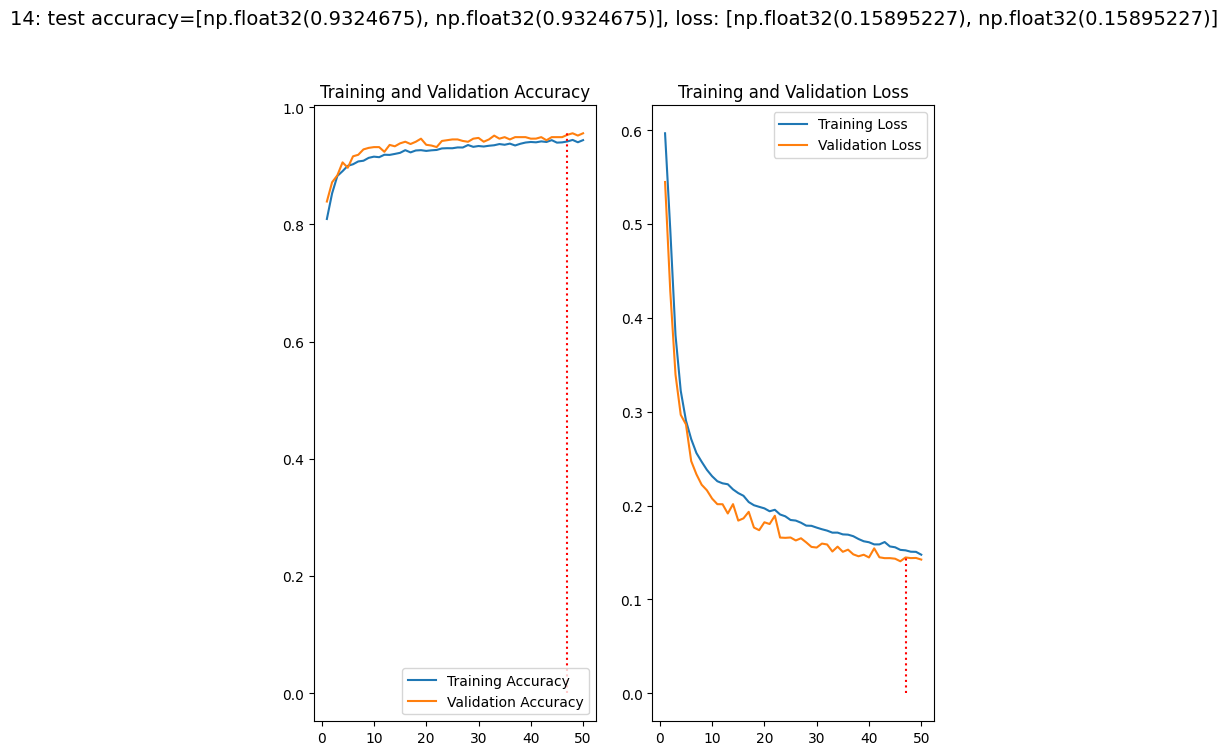

In [6]:
trainer.test()

trainer.plot_performance(name="task4_model_simple.png", group_no="14")

***
#### Q2: What values are optimized during the training process of a CNN? Why isn't the validation accuracy increasing after some time? Why do we use a validation dataset?

#### What values are optimized during the training process of a CNN?
Through backpropagation and gradient descent the weights and biases of the convolutional and fully connected layers.

#### Why isn't the validation accuracy increasing after some time?
Because it overfits the training data and does not generalize (bias)

#### Why do we use a validation dataset?
To detect overfitting during training

### 3 Regularization
#### 3.1 Network Structure

With the basic model you should have achieved a test accuracy of about 95% As you can see on the last model performance, the simple model starts to overfit on the training data. One option to improve generalization is to use regularization. You can add batch normalization and dropout to do so. Update the **MaskClassifier** to include those techniques. Add dropout and batch normalization before suitable layers. Use the dropout parameter passed to the constructor for the dropout rate.

Create a new model with a dropout rate of **dropout=0.5** or **batch_norm=True** and name it **'model_regularized'**. Take a look at the structure of your model by calling ***summary(model2)***. 


In [8]:
model_regularized = my_model.MaskClassifier(
    name="model_regularized",
    img_size=img_size,
    dropout=0.5,
    batch_norm=True
)

summary(model_regularized, (32, 3, img_size, img_size))

Layer (type:depth-idx)                   Output Shape              Param #
MaskClassifier                           [32, 1]                   --
├─Conv2d: 1-1                            [32, 32, 62, 62]          896
├─BatchNorm2d: 1-2                       [32, 32, 62, 62]          64
├─MaxPool2d: 1-3                         [32, 32, 31, 31]          --
├─Conv2d: 1-4                            [32, 32, 29, 29]          9,248
├─BatchNorm2d: 1-5                       [32, 32, 29, 29]          64
├─MaxPool2d: 1-6                         [32, 32, 14, 14]          --
├─Dropout: 1-7                           [32, 6272]                --
├─Linear: 1-8                            [32, 1]                   6,273
Total params: 16,545
Trainable params: 16,545
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 359.30
Input size (MB): 1.57
Forward/backward pass size (MB): 76.76
Params size (MB): 0.07
Estimated Total Size (MB): 78.40

***
#### Q3: Compare the network structure of the model with and without regularization. What will be the effect of the dropout rate you have chosen? What is the effect of batch normalization?

#### Compare the network structure of the model with and without regularization. What will be the effect of the dropout rate you have chosen?
Dropout randomly removes neurons during training, making the network more stable against overfitting.

#### What is the effect of batch normalization?
Stabilizes gradients, makes training faster and improves generalization.

#### 3.2 Training the network

Create a new Trainer object called **trainer2**.
Train the second network, using the same learning rate you used for the first model and set the number of epochs around **50**. 
You can use the same Data Module as for the simple model.


In [9]:
trainer2 = my_trainer.Trainer(
    model = model_regularized,
    datamodule=dm,
    gpu=gpu_active
)

trainer2.fit(
    epochs=50,
    lr=0.0001
)

Epoch 0: 100%|██████████| 42/42 [00:17<00:00,  2.37it/s]


Epoch 0 Training: Loss: 0.45394715666770935 Accuracy: 0.8033424615859985
Epoch 0 Validation: Loss: 0.3779498338699341 Accuracy: 0.870312511920929


Epoch 1: 100%|██████████| 42/42 [00:15<00:00,  2.72it/s]


Epoch 1 Training: Loss: 0.2814067304134369 Accuracy: 0.887963593006134
Epoch 1 Validation: Loss: 0.22660626471042633 Accuracy: 0.9242187142372131


Epoch 2: 100%|██████████| 42/42 [00:15<00:00,  2.63it/s]


...

Epoch 47 Training: Loss: 0.03578953072428703 Accuracy: 0.9892113208770752
Epoch 47 Validation: Loss: 0.1158718392252922 Accuracy: 0.9620659351348877


Epoch 48: 100%|██████████| 42/42 [00:15<00:00,  2.79it/s]


Epoch 48 Training: Loss: 0.034482236951589584 Accuracy: 0.9940476417541504
Epoch 48 Validation: Loss: 0.10789486765861511 Accuracy: 0.9659721851348877


Epoch 49: 100%|██████████| 42/42 [00:15<00:00,  2.72it/s]


Epoch 49 Training: Loss: 0.03023698180913925 Accuracy: 0.9933035969734192
Epoch 49 Validation: Loss: 0.1215403601527214 Accuracy: 0.9581596851348877


#### 3.3 Plot Performance

Plot the performance of the second model with ***trainer2.plot_performance(..)***.

***Submission:*** Save the output of ***trainer2.plot_performance(..)*** as **task4_model_regularized.png**

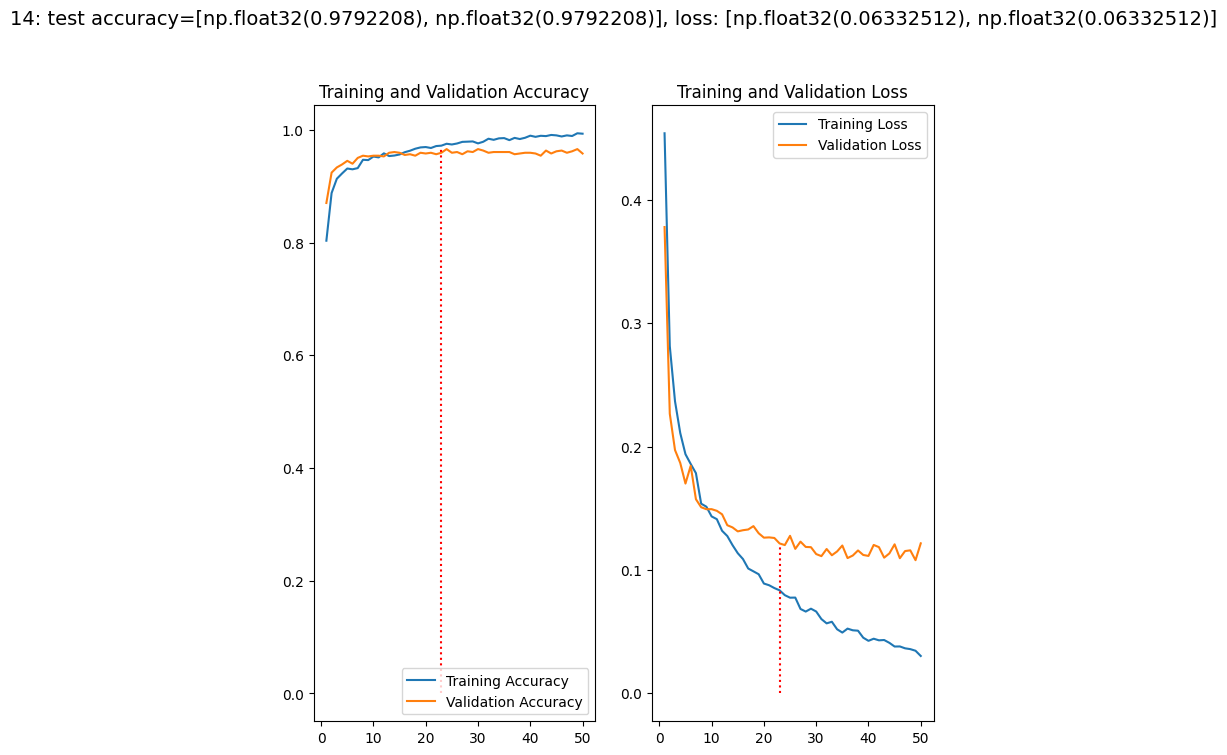

In [10]:
trainer2.test()

trainer2.plot_performance(name="task4_model_regularized.png", group_no="14")

***
#### Q4: Compare the performance of the model with and without regularization. Where do you see improvements?


The training and validation losses do actually diverge, that means there is still overfitting

### 4 Data Augmentation
#### 4.1 Advanced Data Pre-Processing
You will enhance generalization of the network by artificially adding more variety to the training data. Implement data augmentation in **get_transforms** method of **my_datamodule**. Have a look at [torchvision transforms](https://pytorch.org/vision/stable/transforms.html) and choose at least three data augmentation techniques.

In [11]:
dm_augmented = my_datamodule.DataModule(
    img_size=img_size,
    batch_size=64,
    num_workers=4,
    augmented=True
)

#### 4.2 Activation Maps before Training
Create a model with a dropout rate of **60%** and batch normalization. Use a learning rate of approximately **0.0007**. Call the model **'model_augmented'**.

The convolutional layers in the network are initialised with random values. We are going to compare the activation maps before and after the training process. Use ***utils.plot_activation_maps(..)*** to plot some untrained activation maps and filter kernels of the third model. 

Get two image sample of the augmented training dataset with **sample=dm2.train_dataset[...][0]**, one with a mask and one without a mask. Pass each image sample to ***utils.plot_activation_maps(..)***.


***Submission:*** Save the activation maps of the untrained model as **task4_face_activation_maps_before.png** and **task4_mask_activation_maps_before.png** using ***utils.plot_activation_maps(..)***



Total convolutional layers: 2
Total convolutional layers: 2


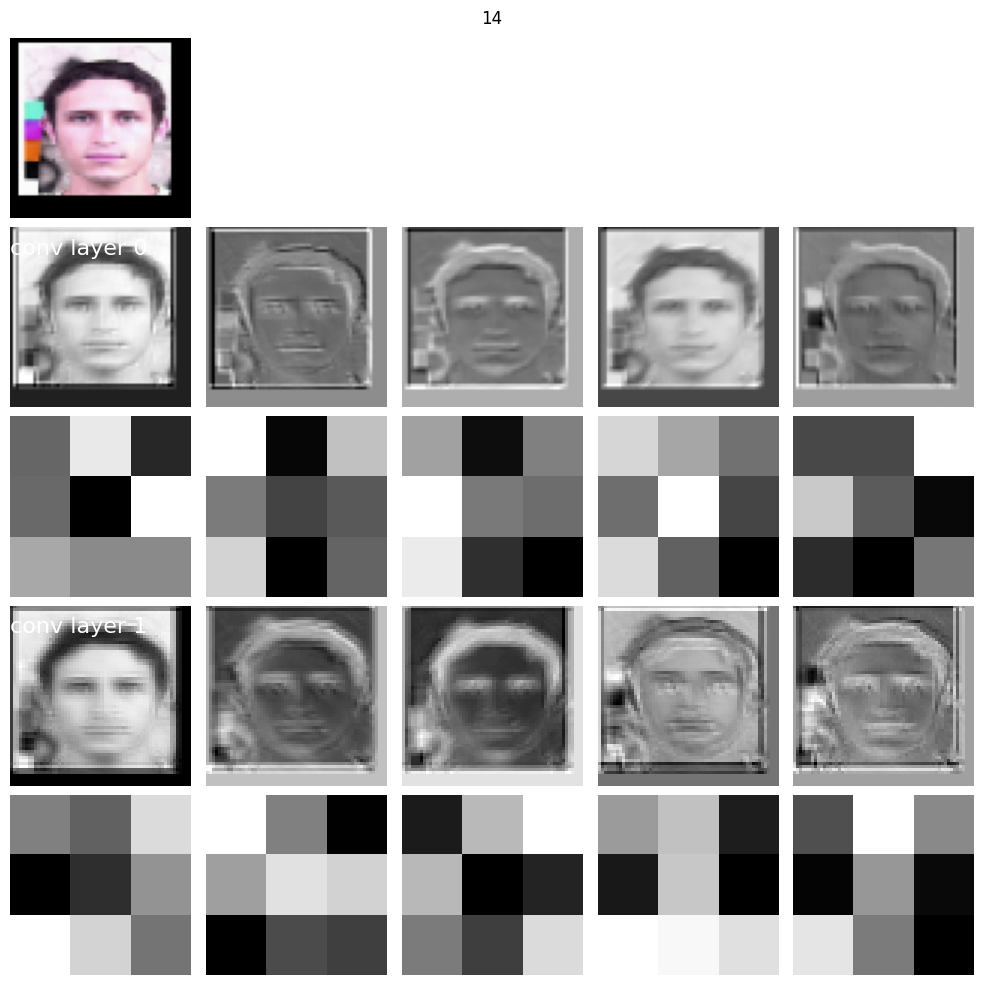

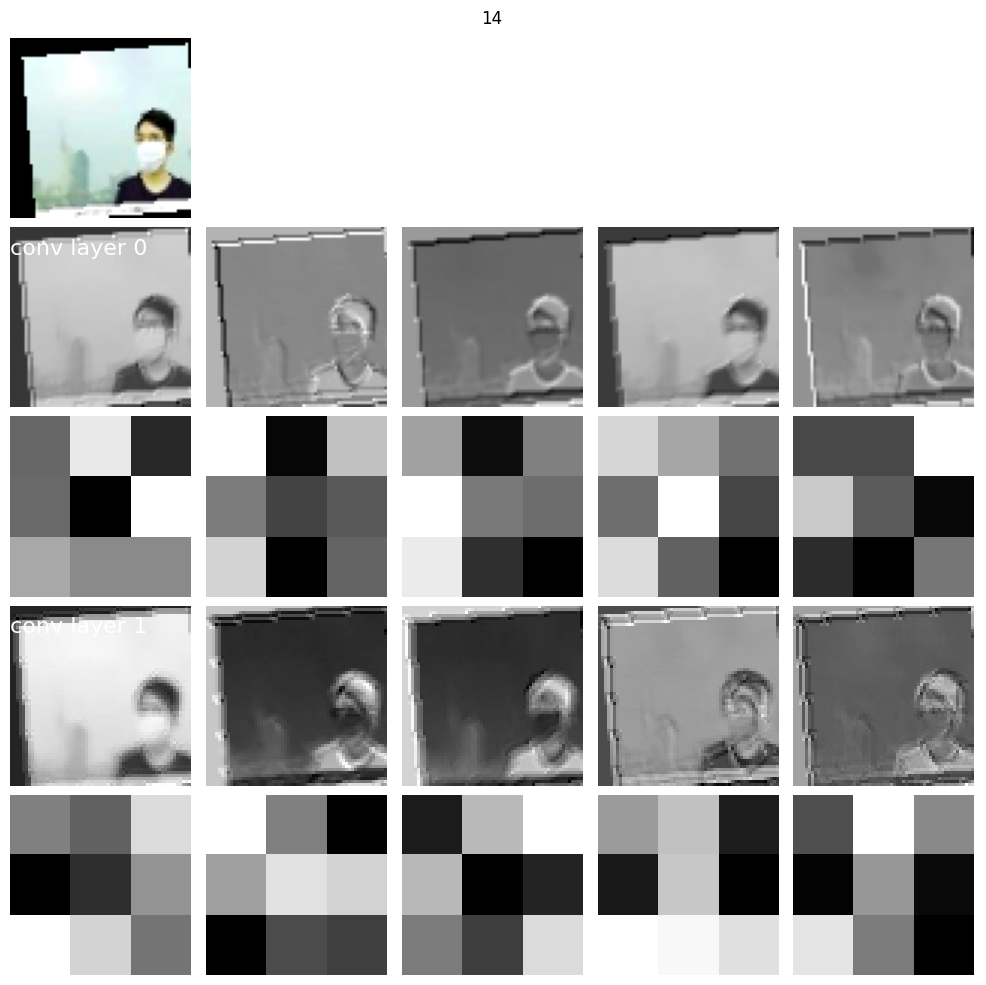

In [ ]:
model_augmented = my_model.MaskClassifier(
    name="model_augmented",
    img_size=img_size,
    dropout=0.6,
    batch_norm=True
)

mask_sample = dm_augmented.train_dataset[0][0]
face_sample = dm_augmented.train_dataset[2001][0]

utils.plot_activation_maps(
    model=model_augmented,
    image_sample=mask_sample,
    group_no="14",
    name="task4_mask_activation_maps_before.png"
)

utils.plot_activation_maps(
    model=model_augmented,
    image_sample=face_sample,
    group_no="14",
    name="task4_face_activation_maps_before.png"
)

#### 4.3 Training the network
Create a third trainer object and train the third network here using the augmented datamodule. Set the epochs to around **100**.

Depending on your hardware this might take longer than the last training sessions.

In [28]:

trainer3 = my_trainer.Trainer(
    model = model_augmented,
    datamodule=dm_augmented,
    gpu=gpu_active
)

trainer3.fit(
    epochs=100
)

Epoch 0: 100%|██████████| 42/42 [00:16<00:00,  2.52it/s]


Epoch 0 Training: Loss: 0.5518309473991394 Accuracy: 0.7204670310020447
Epoch 0 Validation: Loss: 0.40600481629371643 Accuracy: 0.8598089814186096


Epoch 1: 100%|██████████| 42/42 [00:18<00:00,  2.27it/s]


Epoch 1 Training: Loss: 0.36165091395378113 Accuracy: 0.8460107445716858
Epoch 1 Validation: Loss: 0.2541431784629822 Accuracy: 0.9188368320465088


Epoch 2: 100%|██████████| 42/42 [00:16<00:00,  2.52it/s]


...

Epoch 97 Training: Loss: 0.15169040858745575 Accuracy: 0.9412488341331482
Epoch 97 Validation: Loss: 0.09463292360305786 Accuracy: 0.9710069298744202


Epoch 98: 100%|██████████| 42/42 [00:17<00:00,  2.40it/s]


Epoch 98 Training: Loss: 0.15063528716564178 Accuracy: 0.9428227543830872
Epoch 98 Validation: Loss: 0.0998033881187439 Accuracy: 0.9697048664093018


Epoch 99: 100%|██████████| 42/42 [00:15<00:00,  2.68it/s]


Epoch 99 Training: Loss: 0.15051667392253876 Accuracy: 0.9436527490615845
Epoch 99 Validation: Loss: 0.09736541658639908 Accuracy: 0.9697048664093018


#### 4.4. Performance Evaluation 
Plot the model performance of the third model with ***trainer3.plot_performance(..)***.

***Submission:*** Save the output of ***model.plot_curve(..)*** as **task4_model_augmented.png**

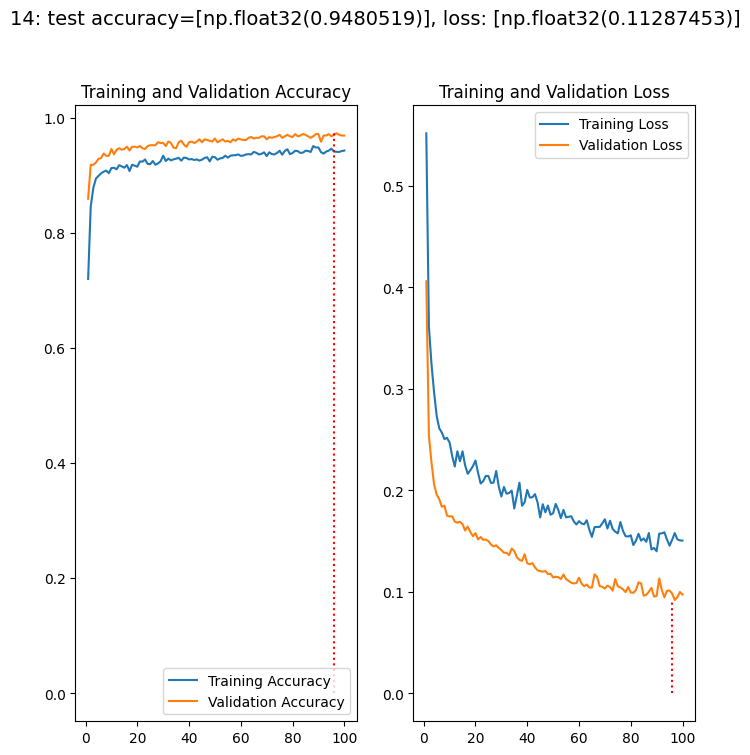

In [29]:
trainer3.plot_performance(name="task4_model_augmented.png", group_no="14")

***
#### Q5: Look at the performance of the third model over time, what do you observe compared to the first two models? Explain underfitting/overfitting based on your plots.

It shows a slower and more stable converge. The training and validation accuracy are following the same trend. In the first two models, after some epochs the accuracy diverges from both sets, therefore overfitting is visible.

The thrid model with augmentation instead shows the least overfitting due to the added images which improves generalization. This way, instead of learning just the training data, it learns the true features which are important for this classification problem. Underfitting can not be seen on this plots, because overfitting is already happening and underfitting happens, when low accuracy is on both training and validation sets.

The last model is by finding a good bias-variance-tradeoff the best model for this task, as it has high accuracy on both sets which dont diverge.

#### 4.5 Activation Maps after Training
During training the weights of the model are adapted to the feature distribution of the training dataset. Plot some activation maps of the third model again using ***utils.plot_activation_maps(..)***. Use the same image samples you used before.

***Submission:*** Save the activation maps after the training as **task4_mask_activation_maps_after.png** and **task4_face_activation_maps_after.png** using ***utils.plot_activation_maps(..)***

Total convolutional layers: 2
Total convolutional layers: 2


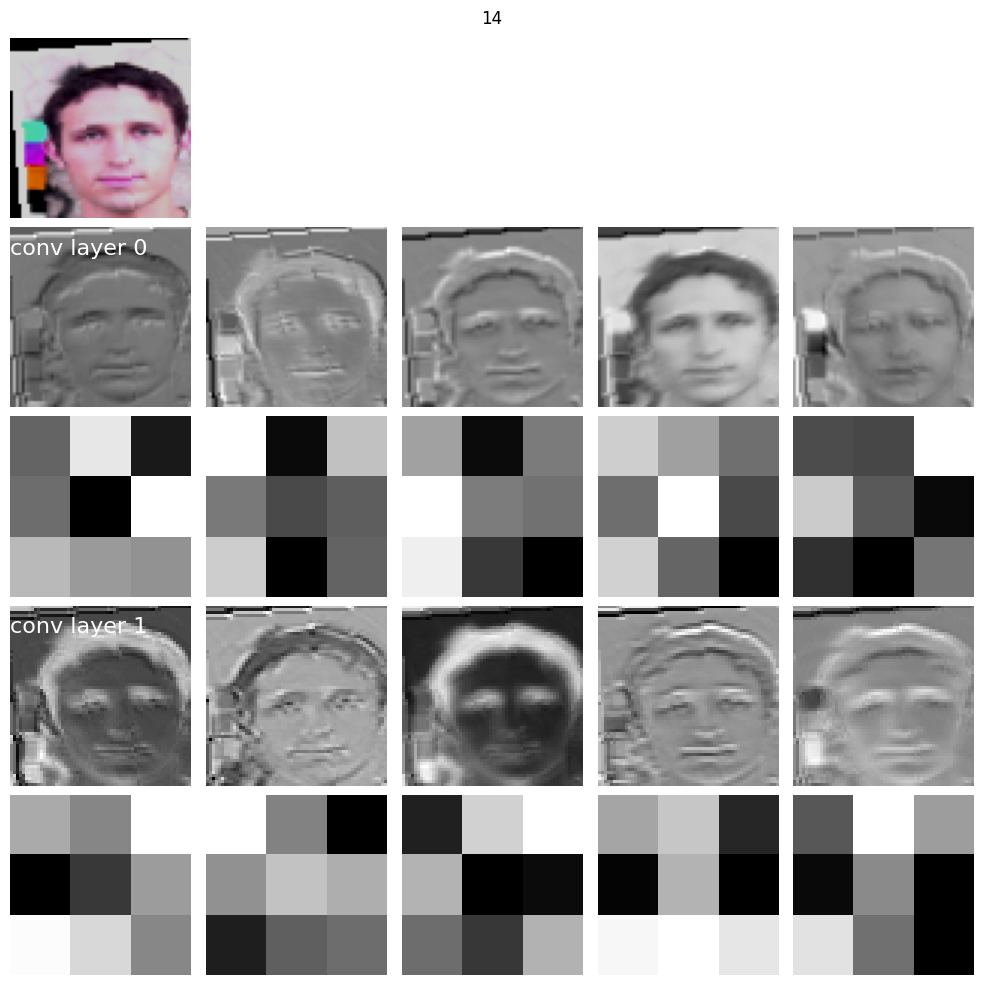

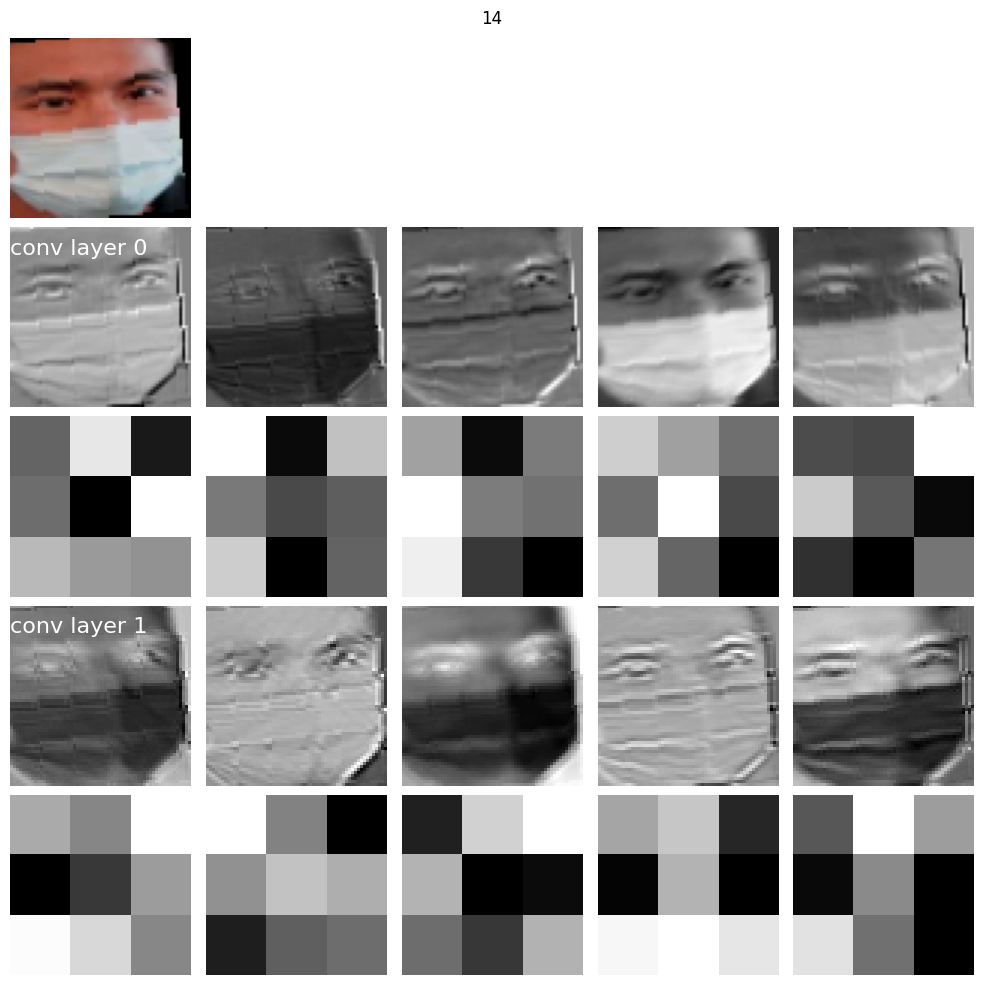

In [38]:
mask_sample_augmented = dm_augmented.train_dataset[0][0]
face_sample_augmented = dm_augmented.train_dataset[2001][0]

utils.plot_activation_maps(
    model=model_augmented,
    image_sample=mask_sample_augmented,
    group_no="14",
    name="task4_mask_activation_maps_after.png"
)

utils.plot_activation_maps(
    model=model_augmented,
    image_sample=face_sample_augmented,
    group_no="14",
    name="task4_face_activation_maps_after.png"
)

***
#### Q6: The activations and filter kernels after the training have changed, what do you observe? Explain possible reasons.


The now learned filters represent more important information like edges and other shape-patterns, especially in the early layer. Later layers focus more on complex shapes based on the simple ones of before.

It is also sparser ans only activates when important information is present (noise/overfitting is not weighted).

Reasons: Backpropagation with loss functions try to minimize it. Regularization and augmentation help the network to learn robust and the true features, to generalize them correctly instead of memorizing the training set.

### 5 Evaluation

Calculate the confusion matrix. You can use the function **confusion_matrix** from **sklearn.metrics**. A confusion matrix within a binary decision problem shows:
 - "true positive" for correctly predicted event values.
 - "false positive" for incorrectly predicted event values.
 - "true negative" for correctly predicted no-event values.
 - "false negative" for incorrectly predicted no-event values.

You can obtain the test data and labes by using **X, y = next(iter(dm2.text_dataloader()))**. Use **trainer3.predict(X)** to obtain the predicted value. You can convert a tensor to a numpy array by using **y.detach().numpy()**. 

In [37]:
from sklearn.metrics import confusion_matrix

X, y = next(iter(dm_augmented.train_dataloader()))

y_pred = trainer3.predict(X)

y = y.detach().numpy()

confusion_matrix(y, y_pred)

array([[29,  0],
       [ 4, 31]])

***
#### Q7: Compare the approach for classification from TASK3 and TASK4. Discuss advantages, disadvantages, strength and weakness. 


Task 3 (bag of visual words) is based on the classification of handcrafted features. Here, algorithms such as SIFT are used  to extract local image features. K-Means is then used to cluster these features. This creates a vocabulary. One advantage of this approach is that it is usually easier to understand (histograms and features) and requires less complex hardware than deep learning models. On the other hand, spatial information is lost in the process. Only the occurrences/frequency of the words are counted, not their positions. In addition, the performance is limited which we see in our results of Bow with an accuracy of 40-50%.

The CNN instead automatically learns features from data without the need of starting with manual feature extraction and learns the important features on its own with simple and complex patterns in the convolution layers. CNN also achieve generally better performance than Bag of words, but require more training data and computational resources and regularazation.